# Lesson 2: Sequential Chats and Customer Onboarding

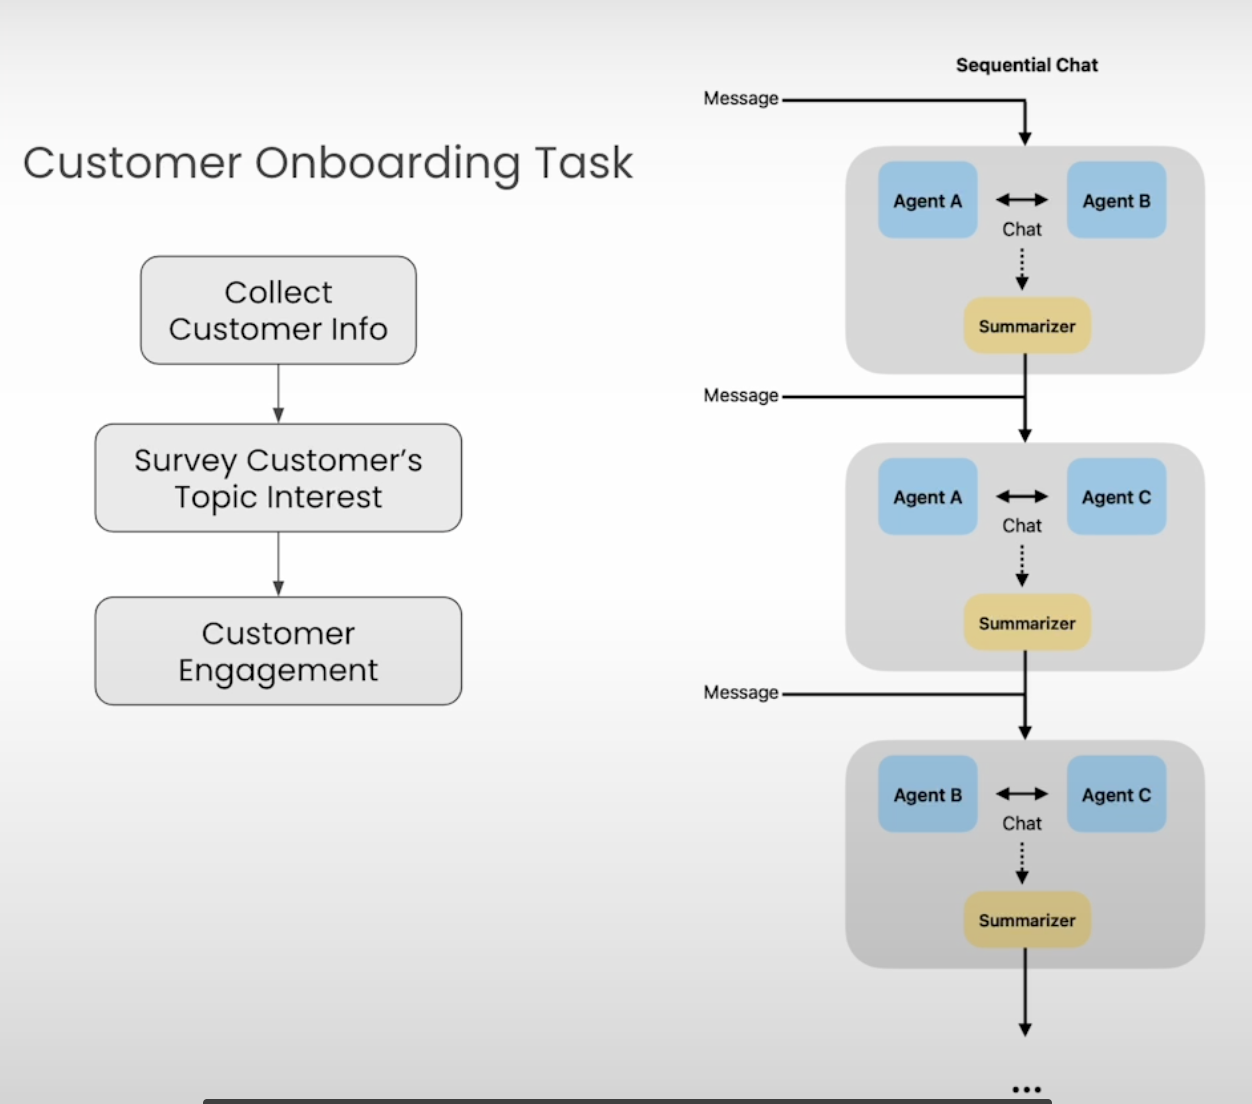

## Setup

In [1]:
llm_config={"model": "gpt-3.5-turbo"}

In [2]:
from autogen import ConversableAgent

## Creating the needed agents

In [3]:
# this asks for customer information
# human input is never, as we are using LLM to generate response from this agent.

onboarding_personal_information_agent = ConversableAgent(
    name="Onboarding Personal Information Agent",
    system_message='''You are a helpful customer onboarding agent,
    you are here to help new customers get started with our product.
    Your job is to gather customer's name and location.
    Do not ask for other information. Return 'TERMINATE' 
    when you have gathered all the information.''',
    llm_config=llm_config,
    code_execution_config=False,
    human_input_mode="NEVER",
)

In [4]:
onboarding_topic_preference_agent = ConversableAgent(
    name="Onboarding Topic preference Agent",
    system_message='''You are a helpful customer onboarding agent,
    you are here to help new customers get started with our product.
    Your job is to gather customer's preferences on news topics.
    Do not ask for other information.
    Return 'TERMINATE' when you have gathered all the information.''',
    llm_config=llm_config,
    code_execution_config=False,
    human_input_mode="NEVER",
)

In [5]:
customer_engagement_agent = ConversableAgent(
    name="Customer Engagement Agent",
    system_message='''You are a helpful customer service agent
    here to provide fun for the customer based on the user's
    personal information and topic preferences.
    This could include fun facts, jokes, or interesting stories.
    Make sure to make it engaging and fun!
    Return 'TERMINATE' when you are done.''',
    llm_config=llm_config,
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda msg: "terminate" in msg.get("content").lower(),
)

In [6]:
# this will act as a human and always asks for input from customers.
customer_proxy_agent = ConversableAgent(
    name="customer_proxy_agent",
    llm_config=False,
    code_execution_config=False,
    human_input_mode="ALWAYS",
    is_termination_msg=lambda msg: "terminate" in msg.get("content").lower(),
)

## Creating tasks

Now, you can craft a series of tasks to facilitate the onboarding process.

In [7]:
# In this each chat, is a chat b/w 2 entities either 2 agents or human & agent.
chats = [
    {
        "sender": onboarding_personal_information_agent,
        "recipient": customer_proxy_agent,
        "message": 
            "Hello, I'm here to help you get started with our product."
            "Could you tell me your name and location?",
        "summary_method": "reflection_with_llm",
        "summary_args": {
            "summary_prompt" : "Return the customer information "
                             "into as JSON object only: "
                             "{'name': '', 'location': ''}",
        },
        "max_turns": 2,
        "clear_history" : True
    },
    {
        "sender": onboarding_topic_preference_agent,
        "recipient": customer_proxy_agent,
        "message": 
                "Great! Could you tell me what topics you are "
                "interested in reading about?",
        "summary_method": "reflection_with_llm",
        "max_turns": 1,
        "clear_history" : False
    },
    {
        "sender": customer_proxy_agent,
        "recipient": customer_engagement_agent,
        "message": "Let's find something fun to read.",
        "max_turns": 1,
        "summary_method": "reflection_with_llm",
    },
]

## Start the onboarding process

**Note**: You might get a slightly different response than what's shown in the video. Feel free to try different inputs, such as name, location, and preferences.

In [8]:
from autogen import initiate_chats

chat_results = initiate_chats(chats)


********************************************************************************
Starting a new chat....

********************************************************************************
Onboarding Personal Information Agent (to customer_proxy_agent):

Hello, I'm here to help you get started with our product.Could you tell me your name and location?

--------------------------------------------------------------------------------


/usr/local/lib/python3.11/site-packages/autogen/agentchat/chat.py:47: UserWarning: Repetitive recipients detected: The chat history will be cleared by default if a recipient appears more than once. To retain the chat history, please set 'clear_history=False' in the configuration of the repeating agent.
  warnings.warn(


Provide feedback to Onboarding Personal Information Agent. Press enter to skip and use auto-reply, or type 'exit' to end the conversation: delhi and bihar
customer_proxy_agent (to Onboarding Personal Information Agent):

delhi and bihar

--------------------------------------------------------------------------------
Onboarding Personal Information Agent (to customer_proxy_agent):

I'm sorry, but I need your name as well. Could you please provide that too?

--------------------------------------------------------------------------------
Provide feedback to Onboarding Personal Information Agent. Press enter to skip and use auto-reply, or type 'exit' to end the conversation: rahul and delhi
customer_proxy_agent (to Onboarding Personal Information Agent):

rahul and delhi

--------------------------------------------------------------------------------

********************************************************************************
Starting a new chat....

*******************************

## Print out the summary

In [9]:
for chat_result in chat_results:
    print(chat_result.summary)
    print("\n")

{'name': 'rahul', 'location': 'delhi'}


rahul from delhi is interested in reading about marvel.


Rahul from Delhi is interested in reading about Marvel. He learned that Iron Man was almost played by Tom Cruise instead of Robert Downey Jr. and that Spider-Man is the most profitable superhero in movie history.




## Print out the cost

In [10]:
for chat_result in chat_results:
    print(chat_result.cost)
    print("\n")

{'usage_including_cached_inference': {'total_cost': 0.00015050000000000003, 'gpt-3.5-turbo-0125': {'cost': 0.00015050000000000003, 'prompt_tokens': 196, 'completion_tokens': 35, 'total_tokens': 231}}, 'usage_excluding_cached_inference': {'total_cost': 0.00015050000000000003, 'gpt-3.5-turbo-0125': {'cost': 0.00015050000000000003, 'prompt_tokens': 196, 'completion_tokens': 35, 'total_tokens': 231}}}


{'usage_including_cached_inference': {'total_cost': 5.2000000000000004e-05, 'gpt-3.5-turbo-0125': {'cost': 5.2000000000000004e-05, 'prompt_tokens': 65, 'completion_tokens': 13, 'total_tokens': 78}}, 'usage_excluding_cached_inference': {'total_cost': 5.2000000000000004e-05, 'gpt-3.5-turbo-0125': {'cost': 5.2000000000000004e-05, 'prompt_tokens': 65, 'completion_tokens': 13, 'total_tokens': 78}}}


{'usage_including_cached_inference': {'total_cost': 0.00042950000000000003, 'gpt-3.5-turbo-0125': {'cost': 0.00042950000000000003, 'prompt_tokens': 316, 'completion_tokens': 181, 'total_tokens': 497